In [3]:
import pandas as pd
import numpy as np

In [4]:
dataset = pd.read_csv('train.csv')
dataset.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64
(593994, 13)


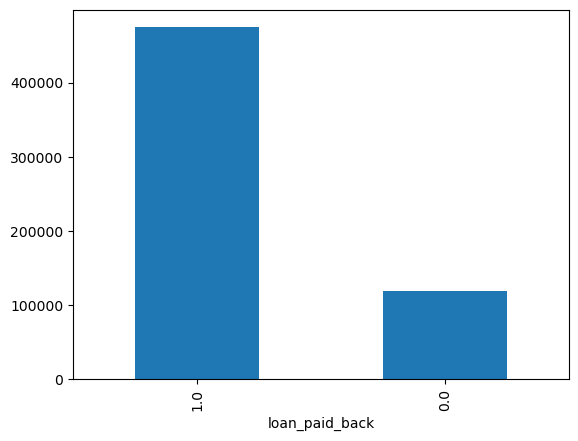

In [7]:
ones = dataset['loan_paid_back'].value_counts()
ones.plot(kind='bar')
print(ones)
print(dataset.shape)

In [8]:
dataset.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [9]:
dataset.drop_duplicates(inplace=True)
print(dataset.shape)

(593994, 13)


In [10]:
from sklearn.preprocessing import LabelEncoder
df_encoded = dataset.copy()
for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

<Axes: >

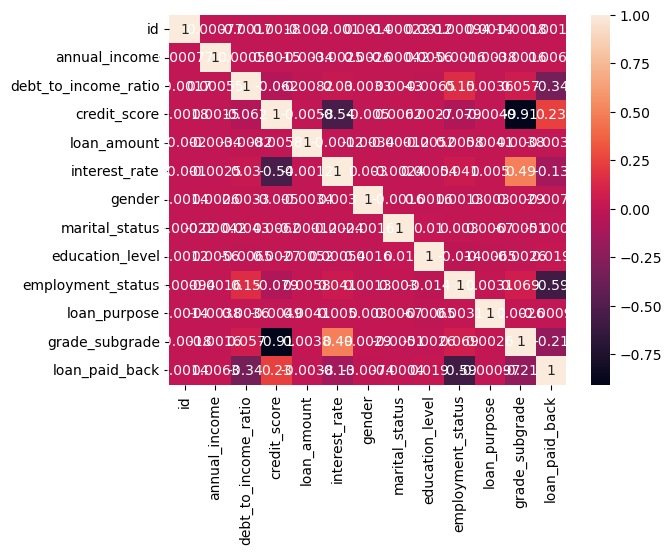

In [11]:
import seaborn as sns
corr = df_encoded.corr()
sns.heatmap(corr, annot=True)

In [12]:
y = df_encoded['loan_paid_back']

In [13]:
X = df_encoded.drop(columns = ['loan_paid_back', 'id'])

In [14]:
X.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,29367.99,0.084,736,2528.42,13.67,0,2,1,2,6,12
1,22108.02,0.166,636,4593.10,12.92,1,1,2,0,2,17
2,49566.20,0.097,694,17005.15,9.76,1,2,1,0,2,14
3,46858.25,0.065,533,4682.48,16.10,0,2,1,0,2,25
4,25496.70,0.053,665,12184.43,10.21,1,1,1,0,6,15


In [17]:
y.head()

0    1.0
1    0.0
2    1.0
3    1.0
4    1.0
Name: loan_paid_back, dtype: float64

In [18]:
from sklearn.model_selection import train_test_split
RNDM_SEED = 12

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = RNDM_SEED)

In [19]:
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_val: {X_val.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_val: {y_val.shape}')

Shape of X_train: (475195, 11)
Shape of X_val: (118799, 11)
Shape of y_train: (475195,)
Shape of y_val: (118799,)


In [20]:
from xgboost import XGBClassifier as XGB
from sklearn.metrics import confusion_matrix, classification_report

good_count = (y == 1).sum()
skrewed_count = (y == 0).sum()

weight = good_count / skrewed_count

model_0 = XGB(scale_pos_weight = weight, random_state = RNDM_SEED)

model_0.fit(X_train, y_train)
y_preds = model_0.predict(X_val)

print(confusion_matrix(y_val, y_preds))
print(classification_report(y_val, y_preds))


[[12213 11560]
 [  489 94537]]
              precision    recall  f1-score   support

         0.0       0.96      0.51      0.67     23773
         1.0       0.89      0.99      0.94     95026

    accuracy                           0.90    118799
   macro avg       0.93      0.75      0.80    118799
weighted avg       0.91      0.90      0.89    118799



### XGBOOST alone did not work, so lets try it with SMOTEEN

In [21]:
from imblearn.combine import SMOTEENN

sme = SMOTEENN()

X_re, y_re = sme.fit_resample(X, y)
Xre_train, Xre_val, yre_train, yre_val = train_test_split(X_re, y_re, test_size = 0.2, random_state = RNDM_SEED)

In [22]:
print(f'Shape of X_re: {X_re.shape}')
print(f'Shape of y_re: {y_re.shape}')

Shape of X_re: (498058, 11)
Shape of y_re: (498058,)


In [23]:
print(f'Shape of Xre_train: {Xre_train.shape}')
print(f'Shape of Xre_val: {Xre_val.shape}')
print(f'Shape of yre_train: {yre_train.shape}')
print(f'Shape of yer_val: {yre_val.shape}')

Shape of Xre_train: (398446, 11)
Shape of Xre_val: (99612, 11)
Shape of yre_train: (398446,)
Shape of yer_val: (99612,)


In [24]:
model_1 = XGB(random_state = RNDM_SEED)
model_1.fit(Xre_train, yre_train)
yre_preds = model_1.predict(Xre_val)

print(confusion_matrix(yre_val, yre_preds))
print(classification_report(yre_val, yre_preds))

[[51299  5479]
 [ 5495 37339]]
              precision    recall  f1-score   support

         0.0       0.90      0.90      0.90     56778
         1.0       0.87      0.87      0.87     42834

    accuracy                           0.89     99612
   macro avg       0.89      0.89      0.89     99612
weighted avg       0.89      0.89      0.89     99612



This worked a lot better. Now lets make predictions on test dataset

# Making predictions on test set

In [25]:
x_test = pd.read_csv('test.csv')
x_test.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


In [26]:
X_testindex = x_test['id']
X_test = x_test.drop(columns = ['id'])

X_test.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


In [27]:
test_encoded = X_test.copy()
for col in test_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    test_encoded[col] = le.fit_transform(test_encoded[col])

In [28]:
test = test_encoded

test.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,28781.05,0.049,626,11461.42,14.73,0,2,1,0,6,19
1,46626.39,0.093,732,15492.25,12.85,0,1,2,0,6,10
2,54954.89,0.367,611,3796.41,13.29,1,2,0,0,2,15
3,25644.63,0.110,671,6574.30,9.57,0,2,0,0,2,12
4,25169.64,0.081,688,17696.89,12.80,0,1,4,0,0,10


Making predicitons

In [29]:
test_preds = model_1.predict(test)

test_preds[:5]

array([1, 1, 0, 1, 1])

In [30]:
test_preds.shape

(254569,)

In [31]:
X_testindex.head()

0    593994
1    593995
2    593996
3    593997
4    593998
Name: id, dtype: int64

In [32]:
x_test.shape

(254569, 12)

In [40]:
Final = pd.DataFrame({'Id':X_testindex,
                      'Test preds':test_preds})
Final

,Id,Test preds
0,593994,1
1,593995,1
2,593996,0
3,593997,1
4,593998,1
...,...,...
254564,848558,1
254565,848559,0
254566,848560,1
254567,848561,1


In [42]:
Final.to_csv('results.csv', index = False)

Final.head()

,Id,Test preds
0,593994,1
1,593995,1
2,593996,0
3,593997,1
4,593998,1
